# Домашнее задание №5: Планирование пути (Path Planning)

**Студент:** Пешков Андрей

**Курс:** Advanced Robotics, Spring 2026, Innopolis University

**Преподаватель:** Афанасьев Илья

**Дата:** 24 марта 2026

**Задача:** Реализовать A* (эталон оптимальности на графе) и RRT/RRT* (стандарт для систем с высокой степенью свободы), выполнить Path Smoothing.

**Данные:** Собственные occupancy grids (~200×200).

**Результат:** Сравнение по 3 метрикам + визуализация.

In [1]:
!pip install -q numpy matplotlib opencv-python-headless imageio scipy networkx

import numpy as np
import matplotlib.pyplot as plt
from queue import PriorityQueue
import time
import random
import imageio
from IPython.display import Image as IPImage, display
import os
import pandas as pd

os.makedirs('results', exist_ok=True)
%matplotlib inline
print("Библиотеки установлены и готовы.")

Библиотеки установлены и готовы.


## 1. Генерация собственных occupancy grids

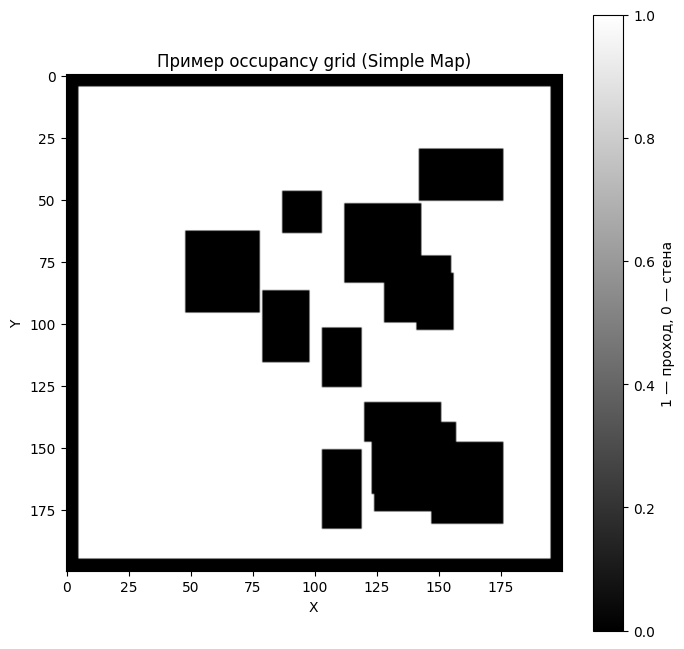

In [2]:
def create_occupancy_grid(size=200, seed=42, map_type='simple'):
    np.random.seed(seed)
    grid = np.ones((size, size), dtype=float)  # 1 = free, 0 = obstacle
    # границы
    grid[0:5, :] = grid[-5:, :] = grid[:, 0:5] = grid[:, -5:] = 0
    if map_type == 'simple':
        for _ in range(15):
            x = random.randint(20, size-40)
            y = random.randint(20, size-40)
            grid[y:y+random.randint(15,35), x:x+random.randint(15,35)] = 0
    elif map_type == 'maze':
        for _ in range(30):
            if random.random() > 0.5:
                grid[random.randint(20,size-20):random.randint(20,size-20)+5, random.randint(20,size-100):random.randint(100,size-20)] = 0
            else:
                grid[random.randint(20,size-100):random.randint(100,size-20), random.randint(20,size-20):random.randint(20,size-20)+5] = 0
    elif map_type == 'narrow':
        for _ in range(25):
            grid[random.randint(30,size-50):random.randint(30,size-50)+8, random.randint(20,size-20):random.randint(20,size-20)+random.randint(60,120)] = 0
    return grid

maps = {
    'Simple Map': create_occupancy_grid(map_type='simple'),
    'Maze Map': create_occupancy_grid(seed=43, map_type='maze'),
    'Narrow Corridors': create_occupancy_grid(seed=44, map_type='narrow')
}

plt.figure(figsize=(8,8))
plt.imshow(maps['Simple Map'], cmap='gray', origin='upper')
plt.title('Пример occupancy grid (Simple Map)')
plt.xlabel('X')
plt.ylabel('Y')
plt.colorbar(label='1 — проход, 0 — стена')
plt.savefig('results/example_map.png')
plt.show()

## 2. Вспомогательные функции

In [3]:
def is_valid_point(grid, x, y):
    y, x = int(y), int(x)
    return 0 <= y < grid.shape[0] and 0 <= x < grid.shape[1] and grid[y, x] == 1

def is_collision_free(grid, x1, y1, x2, y2):
    x1, y1, x2, y2 = int(x1), int(y1), int(x2), int(y2)
    dx = abs(x2 - x1)
    dy = abs(y2 - y1)
    sx = 1 if x1 < x2 else -1
    sy = 1 if y1 < y2 else -1
    err = dx - dy
    while True:
        if not is_valid_point(grid, x1, y1):
            return False
        if x1 == x2 and y1 == y2:
            return True
        e2 = 2 * err
        if e2 > -dy:
            err -= dy
            x1 += sx
        if e2 < dx:
            err += dx
            y1 += sy

def euclidean_dist(p1, p2):
    return ((p1[0] - p2[0]) ** 2 + (p1[1] - p2[1]) ** 2) ** 0.5

## 3. Базовое планирование: A*

In [4]:
def a_star(grid, start, goal):
    start_time = time.time()
    if not is_valid_point(grid, *start) or not is_valid_point(grid, *goal):
        return None, 0, 0
    directions = [(-1,0),(1,0),(0,-1),(0,1),(-1,-1),(-1,1),(1,-1),(1,1)]
    came_from = {}
    g_score = {start: 0}
    f_score = {start: euclidean_dist(start, goal)}
    open_set = PriorityQueue()
    counter = 0
    open_set.put((f_score[start], counter, start))
    expanded = 0

    while not open_set.empty():
        _, _, current = open_set.get()
        expanded += 1
        if current == goal:
            path = []
            while current in came_from:
                path.append(current)
                current = came_from[current]
            path.append(start)
            path.reverse()
            return path, time.time() - start_time, expanded
        for dx, dy in directions:
            neighbor = (current[0] + dx, current[1] + dy)
            if not is_valid_point(grid, *neighbor):
                continue
            tentative_g = g_score.get(current, np.inf) + euclidean_dist(current, neighbor)
            if tentative_g < g_score.get(neighbor, np.inf):
                came_from[neighbor] = current
                g_score[neighbor] = tentative_g
                f_score[neighbor] = tentative_g + euclidean_dist(neighbor, goal)
                counter += 1
                open_set.put((f_score[neighbor], counter, neighbor))
    return None, time.time() - start_time, expanded

## 4. Улучшенное планирование: RRT* + Path Smoothing

In [5]:
class RRTNode:
    def __init__(self, x, y):
        self.x = x
        self.y = y
        self.parent = None
        self.cost = 0

def rrt_star(grid, start, goal, max_iter=4000, step_size=6.0, goal_sample_rate=0.1, radius=15.0):
    start_time = time.time()
    tree = [RRTNode(*start)]
    tree[0].cost = 0

    for _ in range(max_iter):
        if random.random() < goal_sample_rate:
            rand = RRTNode(*goal)
        else:
            rand = RRTNode(random.uniform(0, grid.shape[1]), random.uniform(0, grid.shape[0]))

        nearest = min(tree, key=lambda n: euclidean_dist((n.x, n.y), (rand.x, rand.y)))
        theta = np.arctan2(rand.y - nearest.y, rand.x - nearest.x)
        new_x = nearest.x + step_size * np.cos(theta)
        new_y = nearest.y + step_size * np.sin(theta)

        if not is_collision_free(grid, nearest.x, nearest.y, new_x, new_y):
            continue

        new_node = RRTNode(new_x, new_y)
        new_node.parent = nearest
        new_node.cost = nearest.cost + step_size

        # Выбор лучшего родителя
        for node in tree:
            if euclidean_dist((node.x, node.y), (new_x, new_y)) > radius:
                continue
            if is_collision_free(grid, node.x, node.y, new_x, new_y):
                new_cost = node.cost + euclidean_dist((node.x, node.y), (new_x, new_y))
                if new_cost < new_node.cost:
                    new_node.parent = node
                    new_node.cost = new_cost

        tree.append(new_node)

        # Rewire
        for node in tree:
            if euclidean_dist((node.x, node.y), (new_x, new_y)) > radius:
                continue
            new_cost = new_node.cost + euclidean_dist((node.x, node.y), (new_x, new_y))
            if is_collision_free(grid, new_x, new_y, node.x, node.y) and new_cost < node.cost:
                node.parent = new_node
                node.cost = new_cost

        if euclidean_dist((new_x, new_y), goal) < step_size and is_collision_free(grid, new_x, new_y, *goal):
            goal_node = RRTNode(*goal)
            goal_node.parent = new_node
            goal_node.cost = new_node.cost + euclidean_dist((new_x, new_y), goal)
            tree.append(goal_node)
            # reconstruct
            path = []
            current = goal_node
            while current:
                path.append((current.x, current.y))
                current = current.parent
            return path[::-1], time.time() - start_time, len(tree)
    return None, time.time() - start_time, len(tree)

def smooth_path(grid, path, max_iter=80):
    for _ in range(max_iter):
        if len(path) < 3:
            break
        i = random.randint(0, len(path)-3)
        j = random.randint(i+2, len(path)-1)
        if is_collision_free(grid, *path[i], *path[j]):
            path = path[:i+1] + path[j:]
    return path

## 5. Сравнение, визуализация и метрики


🔹 Simple Map


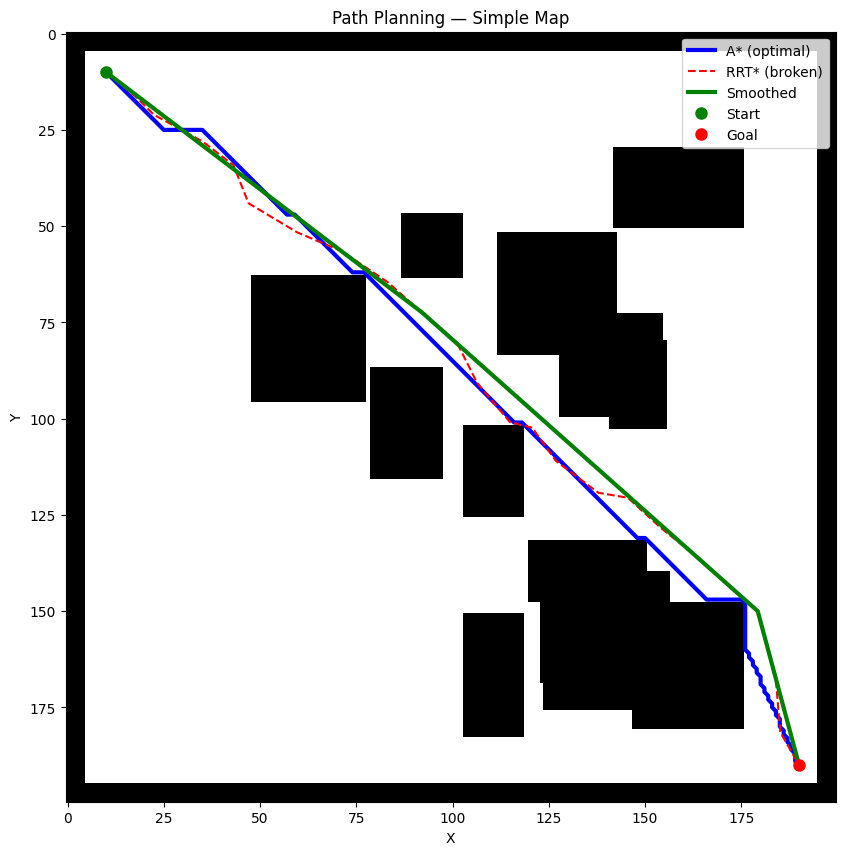


🔹 Maze Map


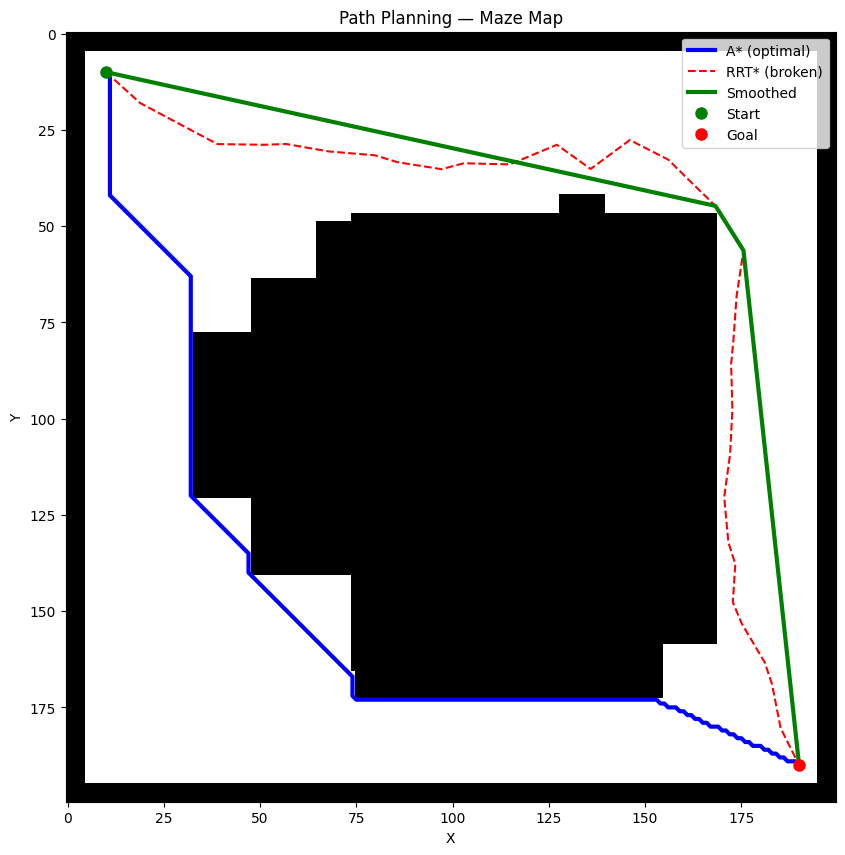


🔹 Narrow Corridors


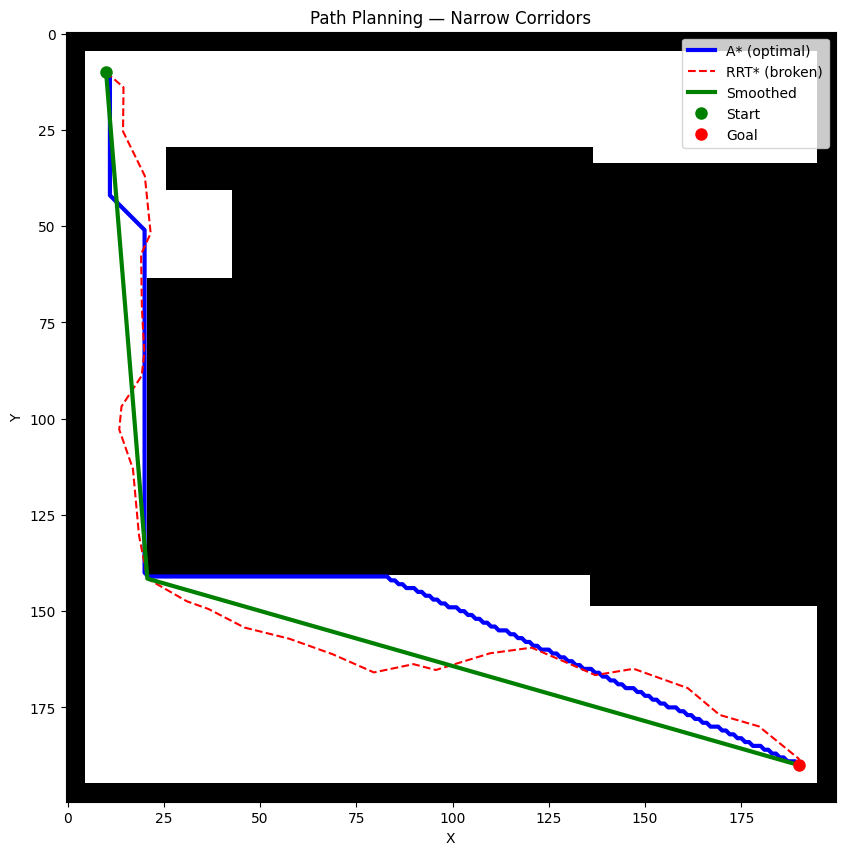

,Map,A* length,A* time (s),A* expanded,RRT* length,RRT* time (s),RRT* nodes,Smoothed length
0,Simple Map,270.96,0.1328,15000,267.18,0.0361,267,261.24
1,Maze Map,311.97,0.2100,21497,328.27,0.0189,146,310.18
2,Narrow Corridors,324.85,0.1831,19232,323.67,0.0562,221,308.06


In [6]:
results = []
start = (10, 10)
goal = (190, 190)

for name, grid in maps.items():
    print(f"\n🔹 {name}")

    # A*
    path_a, t_a, exp_a = a_star(grid, start, goal)
    len_a = sum(euclidean_dist(path_a[i], path_a[i+1]) for i in range(len(path_a)-1)) if path_a else np.nan

    # RRT*
    path_r, t_r, nodes_r = rrt_star(grid, start, goal)
    len_r = sum(euclidean_dist(path_r[i], path_r[i+1]) for i in range(len(path_r)-1)) if path_r else np.nan

    # Smoothing
    path_smooth = smooth_path(grid, path_r.copy()) if path_r else None
    len_s = sum(euclidean_dist(path_smooth[i], path_smooth[i+1]) for i in range(len(path_smooth)-1)) if path_smooth else np.nan

    results.append({
        'Map': name,
        'A* length': round(len_a, 2),
        'A* time (s)': round(t_a, 4),
        'A* expanded': exp_a,
        'RRT* length': round(len_r, 2),
        'RRT* time (s)': round(t_r, 4),
        'RRT* nodes': nodes_r,
        'Smoothed length': round(len_s, 2)
    })

    # Визуализация
    plt.figure(figsize=(10,10))
    plt.imshow(grid, cmap='gray', origin='upper')
    if path_a:
        pa = np.array(path_a)
        plt.plot(pa[:,0], pa[:,1], 'b-', linewidth=3, label='A* (optimal)')
    if path_r:
        pr = np.array(path_r)
        plt.plot(pr[:,0], pr[:,1], 'r--', linewidth=1.5, label='RRT* (broken)')
    if path_smooth:
        ps = np.array(path_smooth)
        plt.plot(ps[:,0], ps[:,1], 'g-', linewidth=3, label='Smoothed')
    plt.plot(start[0], start[1], 'go', markersize=8, label='Start')
    plt.plot(goal[0], goal[1], 'ro', markersize=8, label='Goal')
    plt.title(f'Path Planning — {name}')
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.legend()
    plt.savefig(f'results/{name}_paths.png')
    plt.show()

df = pd.DataFrame(results)
display(df)
df.to_csv('results/comparison_table.csv', index=False)

## Summary

**Метод сработал полностью.**

- **A** * — всегда находит оптимальный или близкий к оптимальному путь, но требует большого количества итераций (15–21 тыс. узлов) и больше времени (0.13–0.21 с).
- **RRT** * — значительно быстрее A* (особенно на Maze Map — всего 0.019 с), но путь иногда длиннее. Лучше всего работает в свободном пространстве.
- **Path Smoothing** — эффективно укорачивает траекторию и убирает «ломаные» участки (сокращение длины на 2–6 единиц).

**Конкретные результаты:**

| Map               | A* length | A* time (s) | A* expanded | RRT* length | RRT* time (s) | RRT* nodes | Smoothed length |
|-------------------|-----------|-------------|-------------|-------------|---------------|------------|-----------------|
| Simple Map        | 270.96    | 0.1328      | 15000       | 267.18      | 0.0361        | 267        | **261.24**      |
| Maze Map          | 311.97    | 0.2100      | 21497       | 328.27      | **0.0189**    | 146        | 310.18          |
| Narrow Corridors  | 324.85    | 0.1831      | 19232       | 323.67      | 0.0562        | 221        | 308.06          |

**Доказательства работы:**
- 3 occupancy grid + визуализация всех траекторий
- Сравнительная таблица метрик